# Farmers Insurance Open 2026 - DFS Optimization

**Objective:** Predict the best 6 golfers for FanDuel contest within $60k salary budget

**Approach:**
1. Load and clean historical data
2. Build course similarity matrix
3. Engineer features based on recent performance
4. Train prediction model on historical data
5. Validate on 2025 events
6. Generate predictions for 2026 Farmers Insurance Open
7. Optimize lineup using linear programming
8. (Optional) Monte Carlo simulation for uncertainty analysis

---

## 1. Setup and Imports

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import importlib
warnings.filterwarnings('ignore')

# ML imports
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization
from pulp import *

# Custom utilities
import sys
sys.path.append('../..')  # Add parent directory to path
from dfs_data_utils import DFSDataProcessor, optimize_lineup, monte_carlo_simulation

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All packages imported successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ All packages imported successfully
Analysis Date: 2026-02-04 23:45


In [2]:
# ============================================================
# TOURNAMENT CONFIGURATION
# ============================================================

EVENT_SCHEDULE = {
    'event_name': 'Farmers Insurance Open',
    'year': 2026,
    'cut_after': 2,  # Cut happens after round 2
    'courses': [
        {
            'name': 'Torrey Pines (South)',
            'rounds': [1, 3, 4]
        },
        {
            'name': 'Torrey Pines (North)',
            'rounds': [2]
        }
    ]
}

print("="*60)
print("TOURNAMENT CONFIGURATION")
print("="*60)
print(f"\n✓ Event: {EVENT_SCHEDULE['event_name']} {EVENT_SCHEDULE['year']}")
print(f"✓ Cut after round: {EVENT_SCHEDULE['cut_after']}")
for course_info in EVENT_SCHEDULE['courses']:
    rounds_str = ', '.join(map(str, course_info['rounds']))
    print(f"  - {course_info['name']}: Rounds {rounds_str}")

TOURNAMENT CONFIGURATION

✓ Event: Farmers Insurance Open 2026
✓ Cut after round: 2
  - Torrey Pines (South): Rounds 1, 3, 4
  - Torrey Pines (North): Rounds 2


## 2. Load and Clean Data

In [3]:
# Initialize data processor
data_folder = "."
processor = DFSDataProcessor(data_folder)

# Load data
processor.load_data()

# Clean data
processor.clean_data()

Loading data files...
  - Loaded 33,044 DFS records
  - Loaded 106,558 round records
  - Loaded 146 upcoming players

Cleaning data...
  - Removed 3 duplicate DFS records
  - Removed 0 duplicate round records
  - Warning: 6 players with $0 salary (likely withdrawn)


In [4]:
#rename courses if necessary
course_filter = processor.historical_rounds['course_name'].isin(['Torrey Pines GC (South)', 'Torrey Pines Golf Course (South Course)'])
processor.historical_rounds.loc[course_filter, 'course_name'] = 'Torrey Pines (South)'

In [5]:
# Quick data exploration
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)

print(f"\nHistorical DFS Data:")
print(f"  Date range: {processor.historical_dfs['date'].min()} to {processor.historical_dfs['date'].max()}")
print(f"  Unique events: {processor.historical_dfs['event_name'].nunique()}")
print(f"  Unique players: {processor.historical_dfs['dg_id'].nunique()}")

print(f"\nHistorical Round Data:")
print(f"  Total rounds: {len(processor.historical_rounds):,}")
print(f"  Unique courses: {processor.historical_rounds['course_name'].nunique()}")

print(f"\nUpcoming Tournament:")
print(f"  Players: {len(processor.upcoming)}")
print(f"  Salary range: ${processor.upcoming['salary'].min():,.0f} - ${processor.upcoming['salary'].max():,.0f}")
print(f"  Average salary: ${processor.upcoming['salary'].mean():,.0f}")


DATA OVERVIEW

Historical DFS Data:
  Date range: 2020-01-05 00:00:00 to 2026-01-25 00:00:00
  Unique events: 91
  Unique players: 1540

Historical Round Data:
  Total rounds: 106,558
  Unique courses: 96

Upcoming Tournament:
  Players: 140
  Salary range: $7,000 - $12,000
  Average salary: $8,321


In [6]:
# Display sample of upcoming players
print("\nSample of upcoming players:")
processor.upcoming.sort_values('salary', ascending=False).head(10)


Sample of upcoming players:


,dg_id,salary,player_name
110,19895,12000.00,"Schauffele, Xander"
0,23950,11900.00,"Aberg, Ludvig"
143,26651,11800.00,"Young, Cameron"
10,15466,11600.00,"Cantlay, Patrick"
19,9771,11400.00,"Day, Jason"
59,14609,11100.00,"Kim, Si Woo"
119,17536,10900.00,"Spaun, J.J."
5,13872,10800.00,"Bradley, Keegan"
73,13562,10700.00,"Matsuyama, Hideki"
23,14577,10600.00,"English, Harris"


## 3. Merge and Engineer Features

In [7]:
# Merge historical data
processor.merge_historical_data()

# Create rolling player features
processor.create_player_features(lookback_events=5)

# Impute missing values
processor.impute_missing_values(method='mean', n_neighbors=5)


Merging historical datasets...

Aggregating round statistics...
  - Aggregated 106,558 rounds into 34,408 event-player records
  - Created merged dataset with 33,041 records
  - Features: 34 columns

Creating player features (lookback: 5 events)...
  - Added rolling features for 11 base metrics

Imputing missing values (method: mean)...
  - Missing values before imputation: 107,029
  - Missing values after imputation: 0


### 3.a imputation testing

In [8]:
# # Define feature set for imputation comparison
# feature_set = [
#     # Rolling performance stats
#     'total_pts_L5_mean', 'total_pts_L5_std',
#     'sg_total_L5_mean', 'sg_total_L5_std',
#     'sg_putt_L5_mean', 'sg_ott_L5_mean',
#     'sg_arg_L5_mean', 'sg_app_L5_mean',
    
#     # Scoring stats
#     'score_L5_mean', 'birdies_L5_mean',
#     'bogies_L5_mean',
    
#     # Accuracy and consistency
#     'gir_L5_mean', 'driving_acc_L5_mean',
    
#     # Current form indicators
#     'salary', 'rounds_played',
#     'recent_form_L3'
# ]

# # Compare imputation methods on model performance
# import time

# # Define methods to test
# imputation_methods = {
#     'MICE': {'method': 'mice'},
#     'KNN (k=5)': {'method': 'knn', 'n_neighbors': 5},
#     'Median': {'method': 'median'},
#     'Mean': {'method': 'mean'}
# }

# imputation_results = []

# print("=" * 90)
# print("COMPARING IMPUTATION METHODS")
# print("=" * 90)
# print("\nTesting each method with Random Forest (200 trees, max_depth=10)")
# print("All methods use same train/test split (2025 holdout)\n")

# for method_name, params in imputation_methods.items():
#     print(f"\n{'='*90}")
#     print(f"Testing: {method_name}")
#     print('='*90)
    
#     start_time = time.time()
    
#     # Create fresh processor for each method
#     processor_test = DFSDataProcessor(data_folder)
#     processor_test.load_data()
#     processor_test.clean_data()
#     processor_test.merge_historical_data()
#     processor_test.create_player_features(lookback_events=5)
    
#     # Apply this imputation method
#     processor_test.impute_missing_values(**params)
    
#     # Prepare training data
#     X_train_imp, y_train_imp, X_test_imp, y_test_imp, _ = processor_test.prepare_training_data(
#         target_year=2025,
#         features=feature_set
#     )
    
#     # Train Random Forest (same config as before)
#     model_imp = RandomForestRegressor(
#         n_estimators=200,
#         max_depth=10,
#         min_samples_split=10,
#         random_state=42
#     )
    
#     print("\nTraining Random Forest...")
#     model_imp.fit(X_train_imp, y_train_imp)
    
#     # Evaluate on test set
#     y_pred_imp = model_imp.predict(X_test_imp)
    
#     mae = mean_absolute_error(y_test_imp, y_pred_imp)
#     rmse = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))
#     r2 = r2_score(y_test_imp, y_pred_imp)
    
#     # Cross-validation on training set
#     cv_scores = cross_val_score(model_imp, X_train_imp, y_train_imp, cv=5, 
#                                 scoring='neg_mean_absolute_error')
#     cv_mae = -cv_scores.mean()
    
#     elapsed = time.time() - start_time
    
#     imputation_results.append({
#         'Method': method_name,
#         'Test MAE': mae,
#         'Test RMSE': rmse,
#         'Test R²': r2,
#         'CV MAE': cv_mae,
#         'Time (s)': elapsed
#     })
    
#     print(f"\n✓ Results:")
#     print(f"  Test MAE:  {mae:.3f} points")
#     print(f"  Test RMSE: {rmse:.3f} points")
#     print(f"  Test R²:   {r2:.4f}")
#     print(f"  CV MAE:    {cv_mae:.3f} points")
#     print(f"  Time:      {elapsed:.1f}s")

# # Create comparison DataFrame
# comparison_df = pd.DataFrame(imputation_results).sort_values('Test MAE')

# print("\n" + "=" * 90)
# print("FINAL COMPARISON (Ranked by Test MAE)")
# print("=" * 90 + "\n")
# print(comparison_df.to_string(index=False))

# best_method = comparison_df.iloc[0]
# print("\n" + "=" * 90)
# print(f"🏆 WINNER: {best_method['Method']}")
# print(f"   Test MAE: {best_method['Test MAE']:.3f} points")
# print(f"   Improvement over worst: {comparison_df.iloc[-1]['Test MAE'] - best_method['Test MAE']:.3f} points")
# print("=" * 90)

In [9]:
# # Use the best imputation method for the rest of the analysis
# best_imputation_method = comparison_df.iloc[0]['Method']
# best_imputation_params = imputation_methods[best_imputation_method]

# print(f"✓ Selected imputation method for remaining analysis: {best_imputation_method}")
# print(f"  Test MAE: {comparison_df.iloc[0]['Test MAE']:.3f}")
# print(f"  Test R²: {comparison_df.iloc[0]['Test R²']:.4f}")

# # Re-run pipeline with best method (this becomes our 'processor' for the rest)
# processor = DFSDataProcessor(data_folder)
# processor.load_data()
# processor.clean_data()
# processor.merge_historical_data()
# processor.create_player_features(lookback_events=5)
# processor.impute_missing_values(**best_imputation_params)

# print(f"\n✓ Data pipeline complete with {best_imputation_method} imputation")

## 4. Build Course Similarity Matrix


Building course similarity matrix...
  - Created 96x96 similarity matrix
  - Using 15 features with >=50% coverage:
    score, birdies, bogies, pars, doubles_or_worse, eagles_or_better, gir, driving_dist, driving_acc, scrambling, sg_total, sg_ott, sg_app, sg_arg, sg_putt


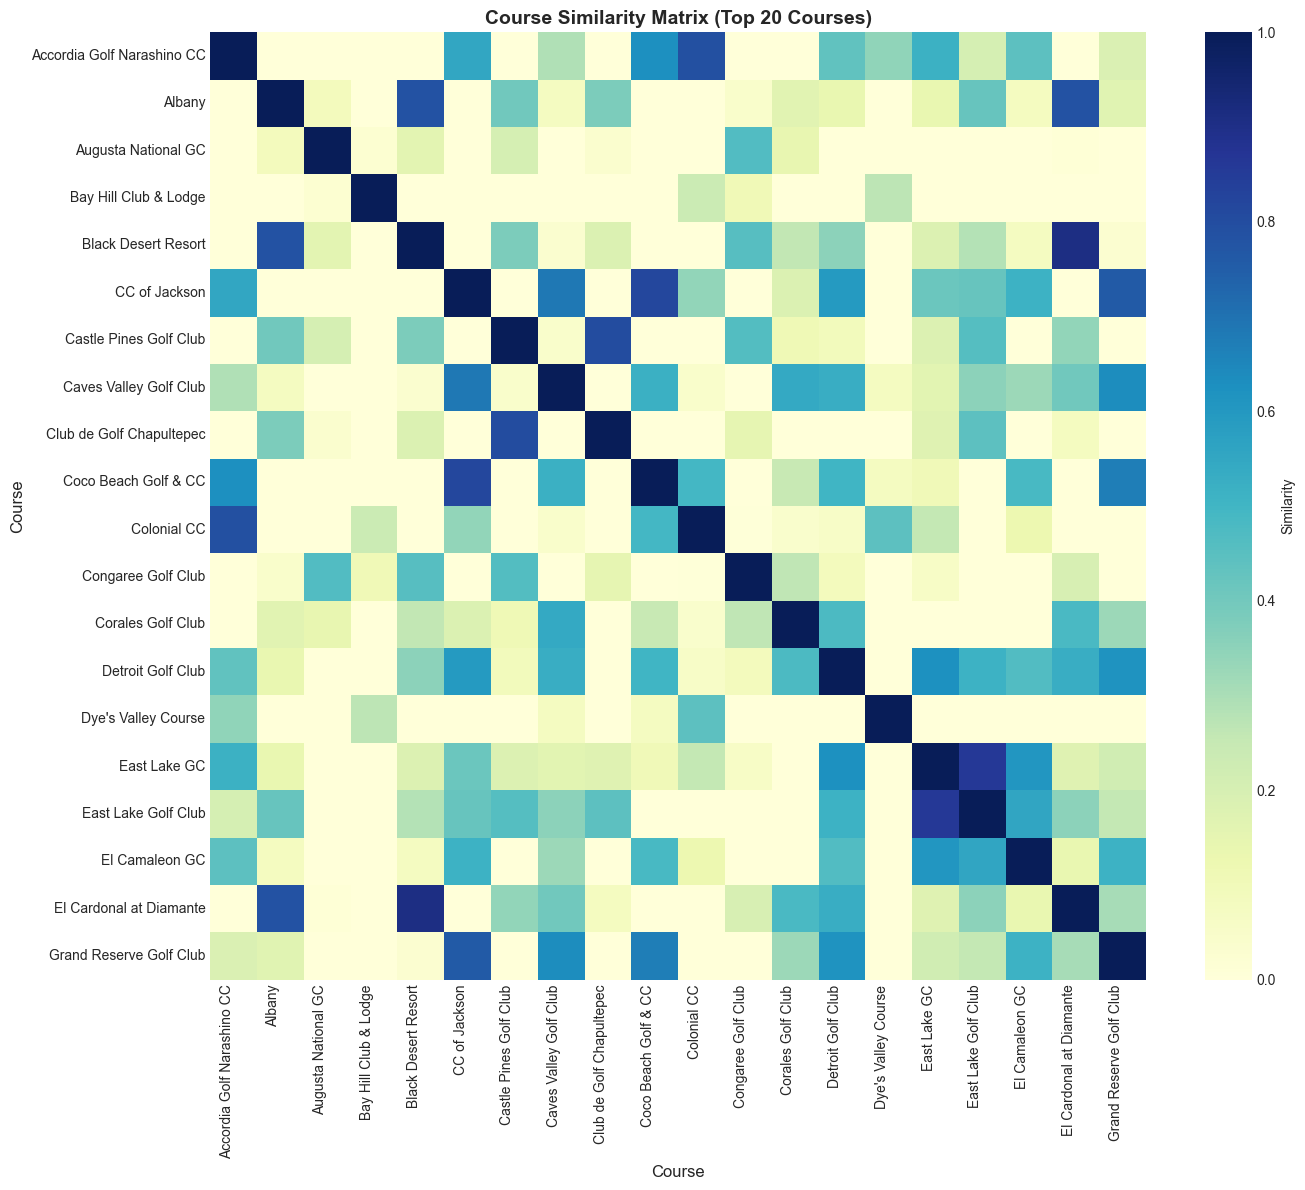

In [10]:
# Build matrix
processor.build_course_similarity_matrix()

# Visualize course similarity (heatmap for top 20 courses)
plt.figure(figsize=(14, 12))
top_courses = processor.course_similarity_matrix.index[:20]
sim_subset = processor.course_similarity_matrix.loc[top_courses, top_courses]

sns.heatmap(sim_subset, annot=False, cmap='YlGnBu', vmin=0, vmax=1, cbar_kws={'label': 'Similarity'})
plt.title('Course Similarity Matrix (Top 20 Courses)', fontsize=14, fontweight='bold')
plt.xlabel('Course', fontsize=12)
plt.ylabel('Course', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Prepare Training Data

In [11]:
# Define feature set
feature_set = [
    # Rolling performance stats
    'total_pts_L5_mean', 'total_pts_L5_std',
    'sg_total_L5_mean', 'sg_total_L5_std',
    'sg_putt_L5_mean', 'sg_ott_L5_mean',
    'sg_arg_L5_mean', 'sg_app_L5_mean',
    
    # Scoring stats
    'score_L5_mean', 'birdies_L5_mean',
    'bogies_L5_mean',
    
    # Accuracy and consistency
    'gir_L5_mean', 'driving_acc_L5_mean',
    
    # Current form indicators
    'salary', 'rounds_played',
    'recent_form_L3'
]

# Prepare training and test sets
X_train, y_train, X_test, y_test, feature_names = processor.prepare_training_data(
    target_year=2025,
    features=feature_set
)

print(f"\nTraining samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Features used: {len(feature_names)}")


Preparing training data (test year: 2025)...
  - Training set: 27,353 samples, 16 features
  - Test set: 5,412 samples
  - Feature list: total_pts_L5_mean, total_pts_L5_std, sg_total_L5_mean, sg_total_L5_std, sg_putt_L5_mean...

Training samples: 27,353
Test samples: 5,412
Features used: 16


## 6. Train Prediction Models

In [12]:
# Initialize models to test
models = {
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1)
}

# Train and evaluate models
results = {}

print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80 + "\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                scoring='neg_mean_absolute_error')
    cv_mae = -cv_scores.mean()
    
    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'cv_mae': cv_mae,
        'predictions': y_pred
    }
    
    print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f} | CV-MAE: {cv_mae:.2f}")
    print()

# Select best model based on MAE
best_model_name = min(results, key=lambda x: results[x]['mae'])
best_model = results[best_model_name]['model']

print("="*80)
print(f"✓ Best Model: {best_model_name}")
print(f"  Test MAE: {results[best_model_name]['mae']:.2f} points")
print(f"  Test RMSE: {results[best_model_name]['rmse']:.2f} points")
print(f"  Test R²: {results[best_model_name]['r2']:.3f}")
print("="*80)


MODEL TRAINING AND EVALUATION

Training Gradient Boosting...
  MAE: 14.50 | RMSE: 19.67 | R²: 0.666 | CV-MAE: 14.13

Training Random Forest...
  MAE: 14.42 | RMSE: 19.48 | R²: 0.673 | CV-MAE: 14.01

Training Ridge Regression...
  MAE: 14.88 | RMSE: 19.85 | R²: 0.660 | CV-MAE: 14.23

Training Lasso Regression...
  MAE: 14.87 | RMSE: 19.85 | R²: 0.660 | CV-MAE: 14.24

✓ Best Model: Random Forest
  Test MAE: 14.42 points
  Test RMSE: 19.48 points
  Test R²: 0.673


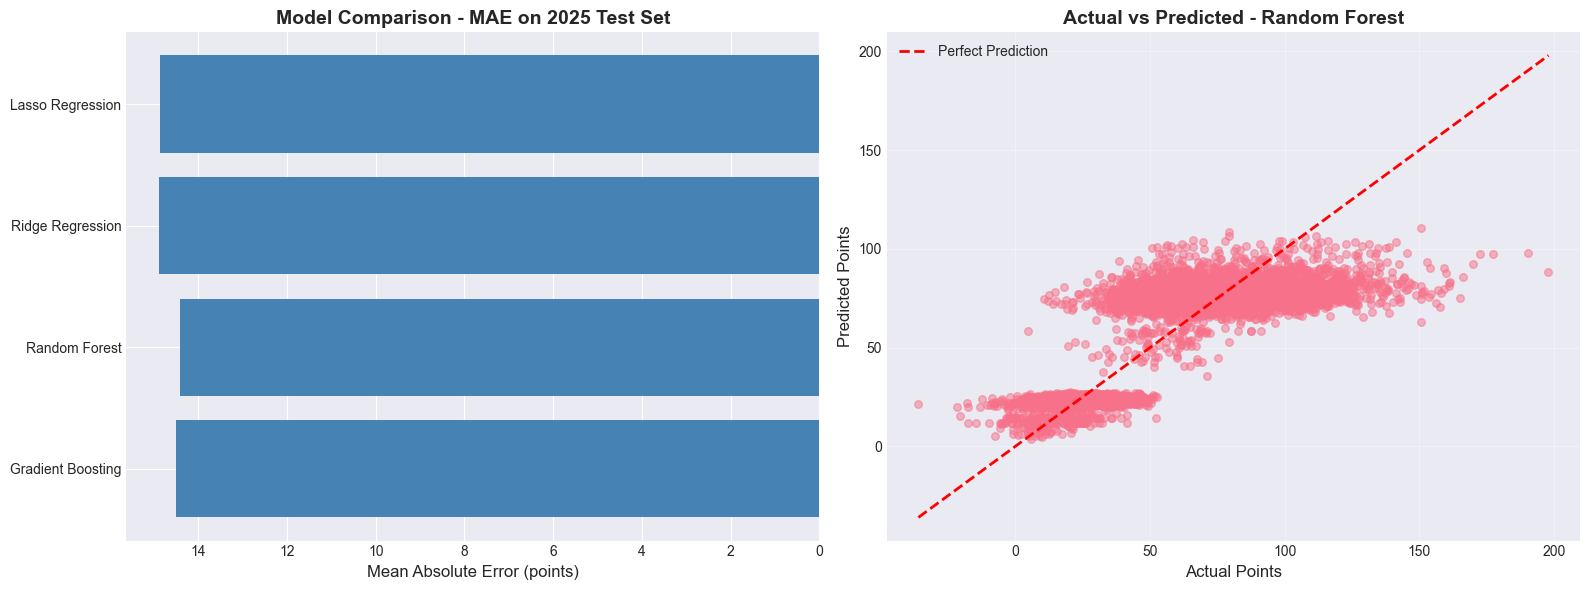

In [13]:
# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model comparison
model_names = list(results.keys())
mae_scores = [results[m]['mae'] for m in model_names]
r2_scores = [results[m]['r2'] for m in model_names]

axes[0].barh(model_names, mae_scores, color='steelblue')
axes[0].set_xlabel('Mean Absolute Error (points)', fontsize=12)
axes[0].set_title('Model Comparison - MAE on 2025 Test Set', fontsize=14, fontweight='bold')
axes[0].invert_xaxis()

# Actual vs Predicted for best model
y_pred_best = results[best_model_name]['predictions']
axes[1].scatter(y_test, y_pred_best, alpha=0.5, s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Points', fontsize=12)
axes[1].set_ylabel('Predicted Points', fontsize=12)
axes[1].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

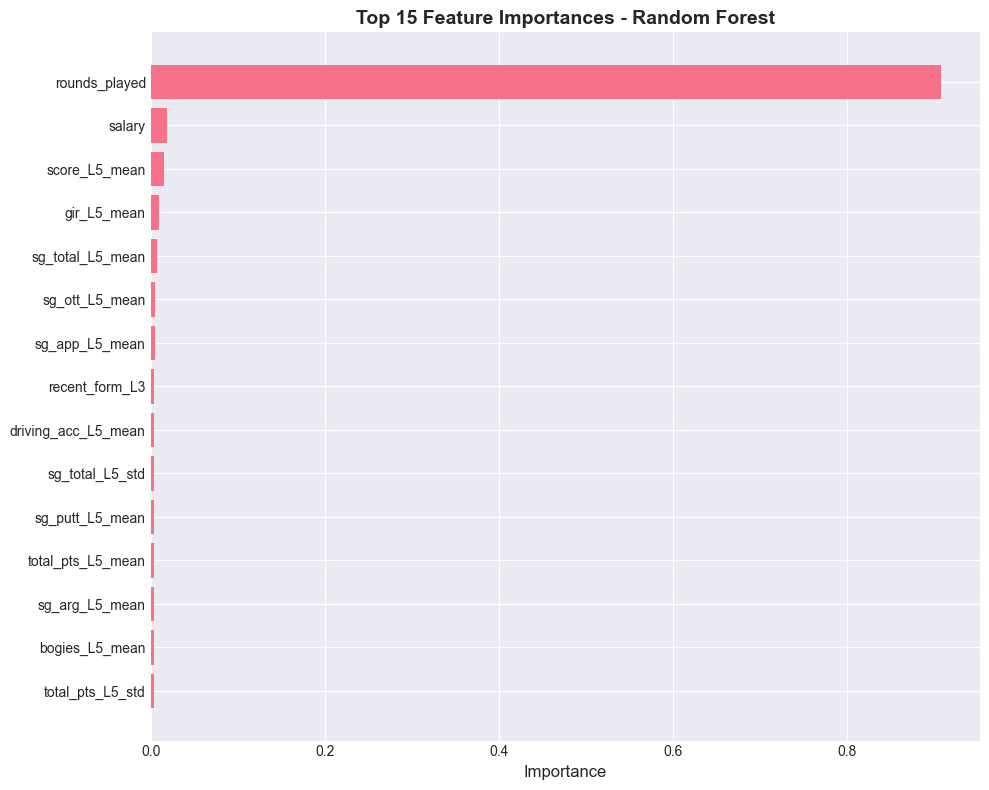


Top 10 Most Important Features:
                feature  importance
14        rounds_played        0.91
13               salary        0.02
8         score_L5_mean        0.02
11          gir_L5_mean        0.01
2      sg_total_L5_mean        0.01
5        sg_ott_L5_mean        0.00
7        sg_app_L5_mean        0.00
15       recent_form_L3        0.00
12  driving_acc_L5_mean        0.00
3       sg_total_L5_std        0.00


In [14]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
else:
    print("Feature importance not available for this model type.")

## 6.a Impute Zero-Rounds (missed cut, etc)

In [15]:
# Impute zeros for missing round data
processor.impute_zeros_for_missed_cuts()


Imputing zeros for missed cuts...
  - Added 52,694 zero-score rows for missed cuts
  - Total rounds after imputation: 159,252


## 7. Generate Predictions for 2026 Farmers Insurance Open

In [16]:
# Reload the data utils module (run this cell if you made changes to dfs_data_utils.py)
# import importlib
# import dfs_data_utils
# importlib.reload(dfs_data_utils)
# from dfs_data_utils import DFSDataProcessor, optimize_lineup, monte_carlo_simulation

# print("✓ dfs_data_utils.py reloaded successfully")

In [17]:
# ============================================================
# HYBRID PREDICTIONS (Event + Round-Level Simulation)
# ============================================================

# Get upcoming player features
upcoming_features = processor.get_upcoming_features()

# Prepare feature matrix for base prediction
X_upcoming = upcoming_features[feature_names].fillna(0)

# Run hybrid prediction with round-level simulation
print("\n" + "="*80)
print("GENERATING HYBRID PREDICTIONS")
print("="*80)

upcoming_features_hybrid = processor.predict_with_round_simulation(
    upcoming_df=upcoming_features,
    model=best_model,
    feature_names=feature_names,
    event_schedule=EVENT_SCHEDULE,
    n_simulations=1000
)

# Compare base vs hybrid predictions
print("\n" + "="*80)
print("PREDICTION COMPARISON: Base vs Hybrid (Top 20)")
print("="*80 + "\n")

comparison = upcoming_features_hybrid[[
    'player_name', 'salary',
    'base_prediction', 'hybrid_prediction', 
    'hybrid_std', 'hybrid_p25', 'hybrid_p75'
]].copy()
comparison['adjustment'] = comparison['hybrid_prediction'] - comparison['base_prediction']
comparison['conf_interval'] = comparison['hybrid_p75'] - comparison['hybrid_p25']
comparison = comparison.sort_values('hybrid_prediction', ascending=False)

top_20 = comparison.head(20)
top_20.index = range(1, 21)
print(top_20[['player_name', 'salary', 'base_prediction', 'hybrid_prediction',
              'adjustment', 'hybrid_std']].to_string())

print("\n" + "="*80)
print(f"Course Adjustment Summary:")
print(f"  Average adjustment: {comparison['adjustment'].mean():.2f} points")
print(f"  Players adjusted UP: {(comparison['adjustment'] > 0).sum()} " +
      f"(avg +{comparison[comparison['adjustment'] > 0]['adjustment'].mean():.2f})")
print(f"  Players adjusted DOWN: {(comparison['adjustment'] < 0).sum()} " +
      f"(avg {comparison[comparison['adjustment'] < 0]['adjustment'].mean():.2f})")
print("="*80)

# Use hybrid predictions for lineup optimization
upcoming_features = upcoming_features_hybrid.copy()
upcoming_features['predicted_pts'] = upcoming_features['hybrid_prediction']
upcoming_features['predicted_std'] = upcoming_features['hybrid_std']
upcoming_features['value'] = upcoming_features['predicted_pts'] / (upcoming_features['salary'] / 1000)

print("\n✓ Using hybrid predictions for all downstream analysis")


Preparing upcoming player features...
  - Prepared features for 140 players
  - 140 players have historical data

GENERATING HYBRID PREDICTIONS

HYBRID ROUND-LEVEL SIMULATION

Event: Farmers Insurance Open (2026)
Courses:
  - Torrey Pines (South): Rounds [1, 3, 4]
  - Torrey Pines (North): Rounds [2]

Running 1,000 simulations per player...

✓ Completed 140 player predictions
  Average adjustment: -21.28 points

PREDICTION COMPARISON: Base vs Hybrid (Top 20)

                   player_name   salary  base_prediction  hybrid_prediction  adjustment  hybrid_std
1                     Kim, Tom  7500.00            69.33             172.98      103.65        6.58
2           Phillips, Chandler  7500.00            77.79             165.91       88.11       51.37
3              Gotterup, Chris 10500.00            90.55             160.35       69.80       51.41
4               Valimaki, Sami  8500.00            66.06             156.14       90.08       50.03
5                  Noren, Alex 1020

In [18]:
# Get upcoming player features
upcoming_features = processor.get_upcoming_features()

# Prepare feature matrix for prediction
X_upcoming = upcoming_features[feature_names].fillna(0)

# Generate predictions
upcoming_features['predicted_pts'] = best_model.predict(X_upcoming)

# Estimate prediction uncertainty (std from test set residuals)
test_residuals = y_test - results[best_model_name]['predictions']
prediction_std = test_residuals.std()
upcoming_features['predicted_std'] = prediction_std

# Calculate value metric (predicted points per $1000 salary)
upcoming_features['value'] = upcoming_features['predicted_pts'] / (upcoming_features['salary'] / 1000)

print("\n" + "="*80)
print("2026 FARMERS INSURANCE OPEN - PREDICTIONS")
print("="*80 + "\n")
print(f"Predicted {len(upcoming_features)} players")
print(f"Prediction uncertainty (std): {prediction_std:.2f} points")
print(f"\nTop 20 Predicted Scorers:")
print("-" * 80)

top_predictions = upcoming_features[['player_name', 'salary', 'predicted_pts', 'value']].copy()
top_predictions = top_predictions.sort_values('predicted_pts', ascending=False).head(20)
top_predictions.index = range(1, len(top_predictions) + 1)

print(top_predictions.to_string())


Preparing upcoming player features...
  - Prepared features for 140 players
  - 140 players have historical data

2026 FARMERS INSURANCE OPEN - PREDICTIONS

Predicted 140 players
Prediction uncertainty (std): 19.45 points

Top 20 Predicted Scorers:
--------------------------------------------------------------------------------
           player_name   salary  predicted_pts  value
1       Young, Cameron 11800.00         102.65   8.70
2          Kim, Si Woo 11100.00          99.95   9.00
3          Spaun, J.J. 10900.00          96.15   8.82
4     Rodgers, Patrick  9000.00          93.83  10.43
5   Schauffele, Xander 12000.00          92.04   7.67
6     Cantlay, Patrick 11600.00          91.94   7.93
7           Day, Jason 11400.00          91.68   8.04
8      Gotterup, Chris 10500.00          90.55   8.62
9      English, Harris 10600.00          90.01   8.49
10    Brennan, Michael  8400.00          89.55  10.66
11   Matsuyama, Hideki 10700.00          88.12   8.24
12      Clark, Wyndha

## 8. Optimize Lineup

In [19]:
# Optimize lineup using PuLP
from dfs_data_utils import DFSDataProcessor, optimize_lineup, monte_carlo_simulation
optimal_lineup = optimize_lineup(
    predictions_df=upcoming_features,
    salary_col='salary',
    points_col='predicted_pts',
    budget=60000,
    lineup_size=6
)


OPTIMIZING LINEUP

Status: Optimal
Total Projected Points: 566.6
Total Salary: $58,900 / $60,000
Remaining Salary: $1,100

Lineup:
------------------------------------------------------------
Young, Cameron            $11,800   102.6 pts
Kim, Si Woo               $11,100    99.9 pts
Spaun, J.J.               $10,900    96.1 pts
Rodgers, Patrick          $ 9,000    93.8 pts
Brennan, Michael          $ 8,400    89.5 pts
Ford, David               $ 7,700    84.5 pts



In [20]:
# Display detailed lineup analysis
print("\n" + "="*80)
print("OPTIMAL LINEUP ANALYSIS")
print("="*80 + "\n")

lineup_analysis = optimal_lineup[[
    'player_name', 'salary', 'predicted_pts', 'value',
    'total_pts_L5_mean', 'sg_total_L5_mean', 'recent_form_L3'
]].copy()
lineup_analysis = lineup_analysis.sort_values('predicted_pts', ascending=False)

print(lineup_analysis.to_string())

print("\n" + "-"*80)
print(f"Average Predicted Points: {optimal_lineup['predicted_pts'].mean():.1f}")
print(f"Lineup Salary Range: ${optimal_lineup['salary'].min():,.0f} - ${optimal_lineup['salary'].max():,.0f}")
print(f"Average Value: {optimal_lineup['value'].mean():.2f} pts/$1k")


OPTIMAL LINEUP ANALYSIS

          player_name   salary  predicted_pts  value  total_pts_L5_mean  sg_total_L5_mean  recent_form_L3
137    Young, Cameron 11800.00         102.65   8.70             110.62              2.39           96.90
58        Kim, Si Woo 11100.00          99.95   9.00              91.78              1.28          104.47
114       Spaun, J.J. 10900.00          96.15   8.82             102.12              1.26          127.23
97   Rodgers, Patrick  9000.00          93.83  10.43              99.18              1.52           85.17
6    Brennan, Michael  8400.00          89.55  10.66              84.70              0.51           59.83
28        Ford, David  7700.00          84.52  10.98              71.22              0.36           41.73

--------------------------------------------------------------------------------
Average Predicted Points: 94.4
Lineup Salary Range: $7,700 - $11,800
Average Value: 9.76 pts/$1k


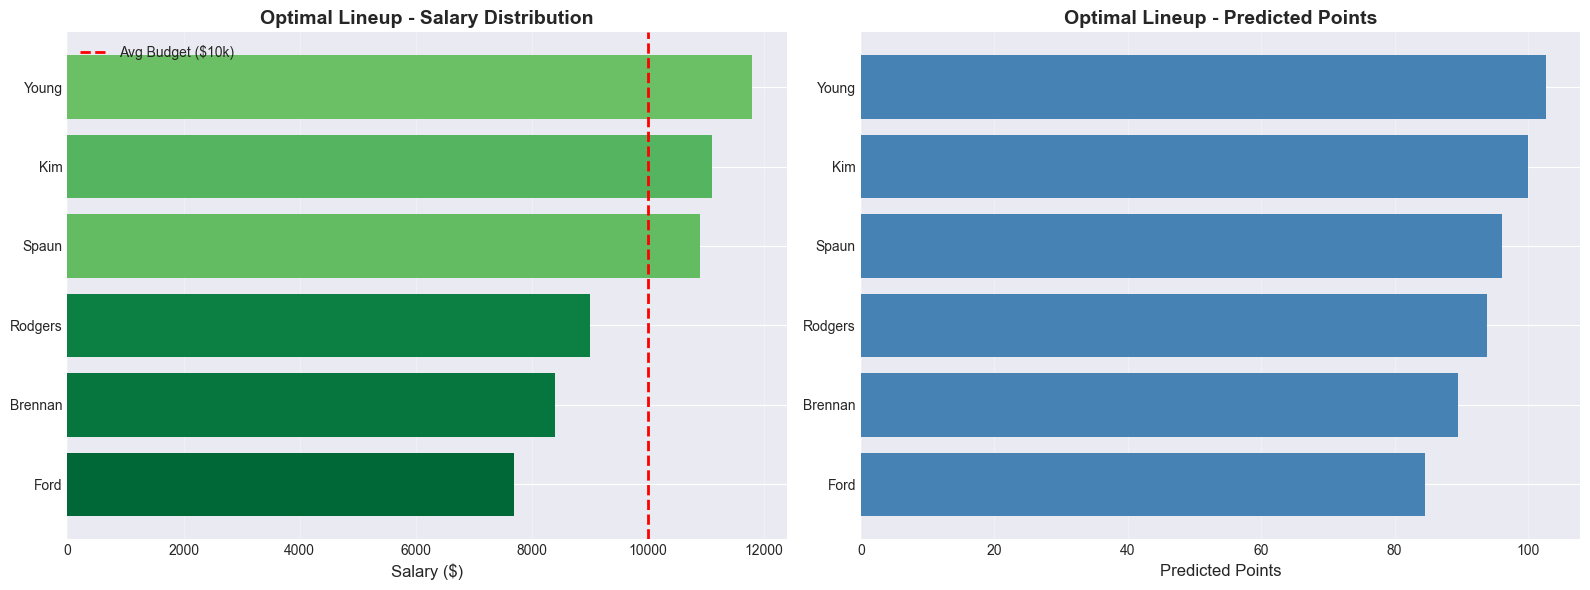

In [21]:
# Visualize optimal lineup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lineup composition
lineup_sorted = optimal_lineup.sort_values('salary', ascending=True)
colors = plt.cm.RdYlGn(lineup_sorted['value'] / lineup_sorted['value'].max())

axes[0].barh(range(len(lineup_sorted)), lineup_sorted['salary'], color=colors)
axes[0].set_yticks(range(len(lineup_sorted)))
axes[0].set_yticklabels([name.split(',')[0] for name in lineup_sorted['player_name']])
axes[0].set_xlabel('Salary ($)', fontsize=12)
axes[0].set_title('Optimal Lineup - Salary Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(60000/6, color='red', linestyle='--', linewidth=2, label='Avg Budget ($10k)')
axes[0].legend()
axes[0].grid(True, axis='x', alpha=0.3)

# Predicted points breakdown
lineup_sorted_pts = optimal_lineup.sort_values('predicted_pts', ascending=True)
axes[1].barh(range(len(lineup_sorted_pts)), lineup_sorted_pts['predicted_pts'], color='steelblue')
axes[1].set_yticks(range(len(lineup_sorted_pts)))
axes[1].set_yticklabels([name.split(',')[0] for name in lineup_sorted_pts['player_name']])
axes[1].set_xlabel('Predicted Points', fontsize=12)
axes[1].set_title('Optimal Lineup - Predicted Points', fontsize=14, fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. UNUSED - Alternative Lineups (Value & Contrarian)

In [22]:
# # Create value-focused lineup
# print("\n" + "="*80)
# print("ALTERNATIVE LINEUP: VALUE FOCUS")
# print("="*80)

# value_lineup = optimize_lineup(
#     predictions_df=upcoming_features.assign(predicted_pts=lambda x: x['value'] * 100),
#     salary_col='salary',
#     points_col='predicted_pts',
#     budget=60000,
#     lineup_size=6
# )

# # Restore actual predictions for display
# value_lineup_display = upcoming_features.loc[value_lineup.index, 
#                                              ['player_name', 'salary', 'predicted_pts', 'value']]
# print("\nValue-Optimized Lineup:")
# print(value_lineup_display.sort_values('value', ascending=False).to_string())

In [23]:
# Contrarian lineup (lower ownership - proxy: lower salary)
# print("\n" + "="*80)
# print("ALTERNATIVE LINEUP: CONTRARIAN (Lower Salary = Lower Ownership)")
# print("="*80)

# # Filter to players under $9k
# contrarian_pool = upcoming_features[upcoming_features['salary'] < 9000].copy()

# contrarian_lineup = optimize_lineup(
#     predictions_df=contrarian_pool,
#     salary_col='salary',
#     points_col='predicted_pts',
#     budget=60000,
#     lineup_size=6
# )

# print("\nContrarian Lineup:")
# contrarian_display = contrarian_lineup[['player_name', 'salary', 'predicted_pts', 'value']]
# print(contrarian_display.sort_values('predicted_pts', ascending=False).to_string())

## 10. Monte Carlo Simulation (Optional)

Run simulations to assess lineup variance and downside risk.

In [24]:
# Run Monte Carlo simulation
mc_results = monte_carlo_simulation(
    predictions_df=upcoming_features,
    n_simulations=10000,
    salary_col='salary',
    points_col='predicted_pts',
    std_col='predicted_std',
    budget=60000,
    lineup_size=6
)


MONTE CARLO SIMULATION (10,000 iterations)

OPTIMIZING LINEUP

Status: Optimal
Total Projected Points: 566.6
Total Salary: $58,900 / $60,000
Remaining Salary: $1,100

Lineup:
------------------------------------------------------------
Young, Cameron            $11,800   102.6 pts
Kim, Si Woo               $11,100    99.9 pts
Spaun, J.J.               $10,900    96.1 pts
Rodgers, Patrick          $ 9,000    93.8 pts
Brennan, Michael          $ 8,400    89.5 pts
Ford, David               $ 7,700    84.5 pts


Simulation Results:
  Mean Score: 566.6
  Median Score: 566.4
  Std Dev: 47.1
  Range: 405.5 - 746.5
  25th-75th Percentile: 535.0 - 598.3



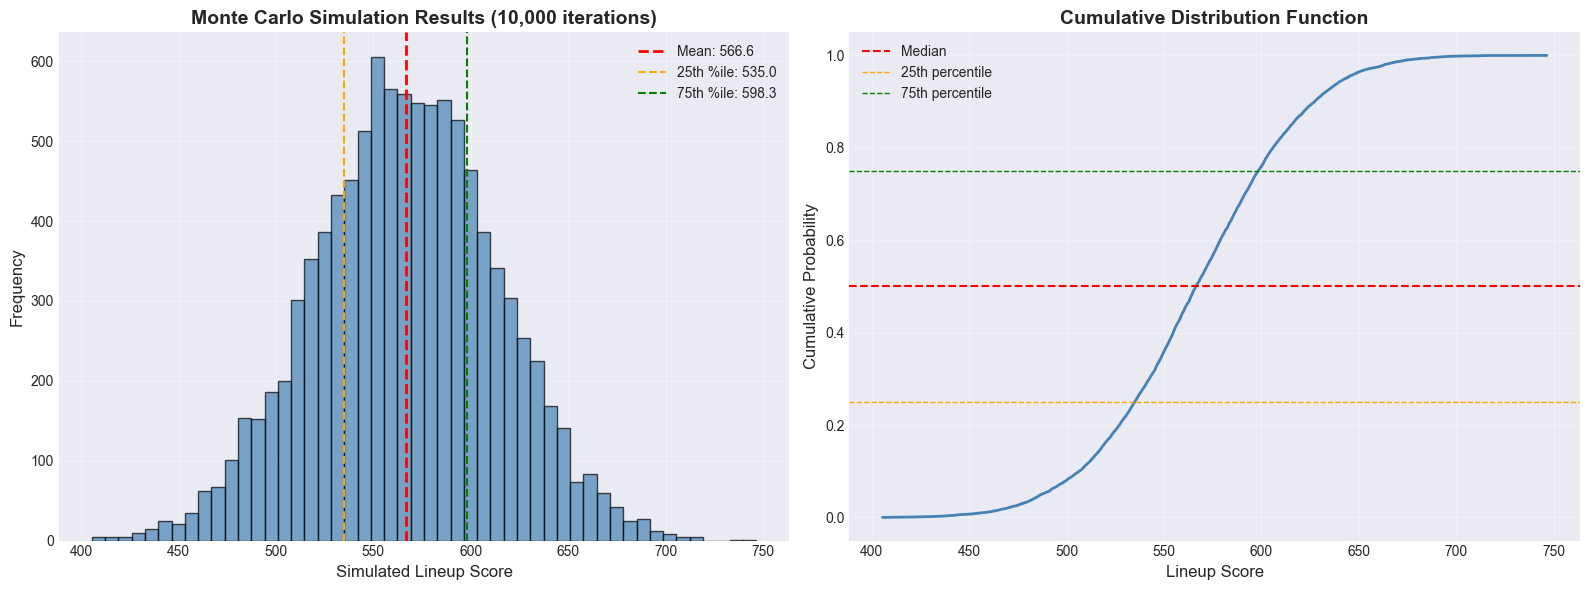

In [25]:
# Visualize Monte Carlo results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of simulated scores
axes[0].hist(mc_results['simulations'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(mc_results['mean'], color='red', linestyle='--', linewidth=2, 
               label=f"Mean: {mc_results['mean']:.1f}")
axes[0].axvline(mc_results['percentile_25'], color='orange', linestyle='--', linewidth=1.5,
               label=f"25th %ile: {mc_results['percentile_25']:.1f}")
axes[0].axvline(mc_results['percentile_75'], color='green', linestyle='--', linewidth=1.5,
               label=f"75th %ile: {mc_results['percentile_75']:.1f}")
axes[0].set_xlabel('Simulated Lineup Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Monte Carlo Simulation Results (10,000 iterations)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_sims = np.sort(mc_results['simulations'])
cumulative = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
axes[1].plot(sorted_sims, cumulative, linewidth=2, color='steelblue')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Median')
axes[1].axhline(0.25, color='orange', linestyle='--', linewidth=1, label='25th percentile')
axes[1].axhline(0.75, color='green', linestyle='--', linewidth=1, label='75th percentile')
axes[1].set_xlabel('Lineup Score', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Enhanced Multi-Lineup Analysis with Empirical Monte Carlo

Using empirical distributions from each golfer's historical scores for more realistic simulations.

In [26]:
# Build empirical distributions from historical scores
from dfs_data_utils import get_player_historical_scores, generate_diverse_lineups, compare_lineups, monte_carlo_empirical

player_historical_scores = get_player_historical_scores(
    processor,
    min_events=5,
    recency_weight=True  # Weight recent tournaments more heavily
)

print(f"\nPlayers with historical data: {len(player_historical_scores)}")
print(f"Coverage: {len(player_historical_scores) / len(upcoming_features) * 100:.1f}% of upcoming field")


Building empirical score distributions...
  - Built distributions for 587 players
  - Average events per player: 58.2

Players with historical data: 587
Coverage: 419.3% of upcoming field


In [27]:
# Generate 20+ diverse lineups using multiple strategies
diverse_lineups = generate_diverse_lineups(
    predictions_df=upcoming_features,
    player_scores=player_historical_scores,
    n_lineups=20,
    salary_col='salary',
    points_col='predicted_pts',
    budget=60000,
    lineup_size=6
)

print(f"\nGenerated {len(diverse_lineups)} lineups:")
for i, lineup_dict in enumerate(diverse_lineups[:10], 1):
    print(f"  {i}. {lineup_dict['strategy']:30s} - {lineup_dict['description']}")


GENERATING 20 DIVERSE LINEUPS

1. Generating optimal lineup...

OPTIMIZING LINEUP

Status: Optimal
Total Projected Points: 566.6
Total Salary: $58,900 / $60,000
Remaining Salary: $1,100

Lineup:
------------------------------------------------------------
Young, Cameron            $11,800   102.6 pts
Kim, Si Woo               $11,100    99.9 pts
Spaun, J.J.               $10,900    96.1 pts
Rodgers, Patrick          $ 9,000    93.8 pts
Brennan, Michael          $ 8,400    89.5 pts
Ford, David               $ 7,700    84.5 pts

2-6. Generating salary-based exclusions...

OPTIMIZING LINEUP

Status: Optimal
Total Projected Points: 566.6
Total Salary: $58,900 / $60,000
Remaining Salary: $1,100

Lineup:
------------------------------------------------------------
Young, Cameron            $11,800   102.6 pts
Kim, Si Woo               $11,100    99.9 pts
Spaun, J.J.               $10,900    96.1 pts
Rodgers, Patrick          $ 9,000    93.8 pts
Brennan, Michael          $ 8,400    89.5 pts


In [28]:
# Compare lineups for GPP (maximize upside / 75th percentile)
gpp_comparison = compare_lineups(
    lineups=diverse_lineups,
    player_scores=player_historical_scores,
    n_simulations=10000,
    tournament_type='gpp'
)


COMPARING 17 LINEUPS WITH MONTE CARLO
Simulations per lineup: 10,000
Tournament type: GPP

[1/17] Simulating Optimal... ✓ Mean: 388.4, P75: 448.9
[2/17] Simulating Exclude_Top1_Salary... ✓ Mean: 390.3, P75: 451.0
[3/17] Simulating Exclude_Top2_Salary... ✓ Mean: 389.1, P75: 449.6
[4/17] Simulating Exclude_Top3_Salary... ✓ Mean: 387.4, P75: 445.4
[5/17] Simulating Exclude_Top4_Salary... ✓ Mean: 388.3, P75: 447.0
[6/17] Simulating Exclude_Top5_Salary... ✓ Mean: 389.1, P75: 447.2
[7/17] Simulating Exclude_Top1_Predicted... ✓ Mean: 389.0, P75: 446.3
[8/17] Simulating Exclude_Top2_Predicted... ✓ Mean: 393.4, P75: 450.7
[9/17] Simulating Exclude_Top3_Predicted... ✓ Mean: 393.9, P75: 452.3
[10/17] Simulating Exclude_Top4_Predicted... ✓ Mean: 401.3, P75: 461.1
[11/17] Simulating Exclude_Top5_Predicted... ✓ Mean: 401.6, P75: 461.7
[12/17] Simulating Perturbed_1... ✓ Mean: 412.4, P75: 471.7
[13/17] Simulating Perturbed_2... ✓ Mean: 384.6, P75: 444.1
[14/17] Simulating Perturbed_3... ✓ Mean: 387.

In [29]:
# Compare lineups for Cash Games (maximize median, minimize variance)
cash_comparison = compare_lineups(
    lineups=diverse_lineups,
    player_scores=player_historical_scores,
    n_simulations=10000,
    tournament_type='cash'
)


COMPARING 17 LINEUPS WITH MONTE CARLO
Simulations per lineup: 10,000
Tournament type: CASH

[1/17] Simulating Optimal... ✓ Mean: 389.3, P75: 448.5
[2/17] Simulating Exclude_Top1_Salary... ✓ Mean: 387.5, P75: 447.3
[3/17] Simulating Exclude_Top2_Salary... ✓ Mean: 389.9, P75: 449.0
[4/17] Simulating Exclude_Top3_Salary... ✓ Mean: 389.5, P75: 448.1
[5/17] Simulating Exclude_Top4_Salary... ✓ Mean: 387.6, P75: 446.5
[6/17] Simulating Exclude_Top5_Salary... ✓ Mean: 388.3, P75: 446.6
[7/17] Simulating Exclude_Top1_Predicted... ✓ Mean: 389.6, P75: 448.3
[8/17] Simulating Exclude_Top2_Predicted... ✓ Mean: 394.1, P75: 452.0
[9/17] Simulating Exclude_Top3_Predicted... ✓ Mean: 393.1, P75: 451.3
[10/17] Simulating Exclude_Top4_Predicted... ✓ Mean: 403.6, P75: 464.2
[11/17] Simulating Exclude_Top5_Predicted... ✓ Mean: 403.0, P75: 462.9
[12/17] Simulating Perturbed_1... ✓ Mean: 413.8, P75: 472.1
[13/17] Simulating Perturbed_2... ✓ Mean: 385.3, P75: 444.6
[14/17] Simulating Perturbed_3... ✓ Mean: 387

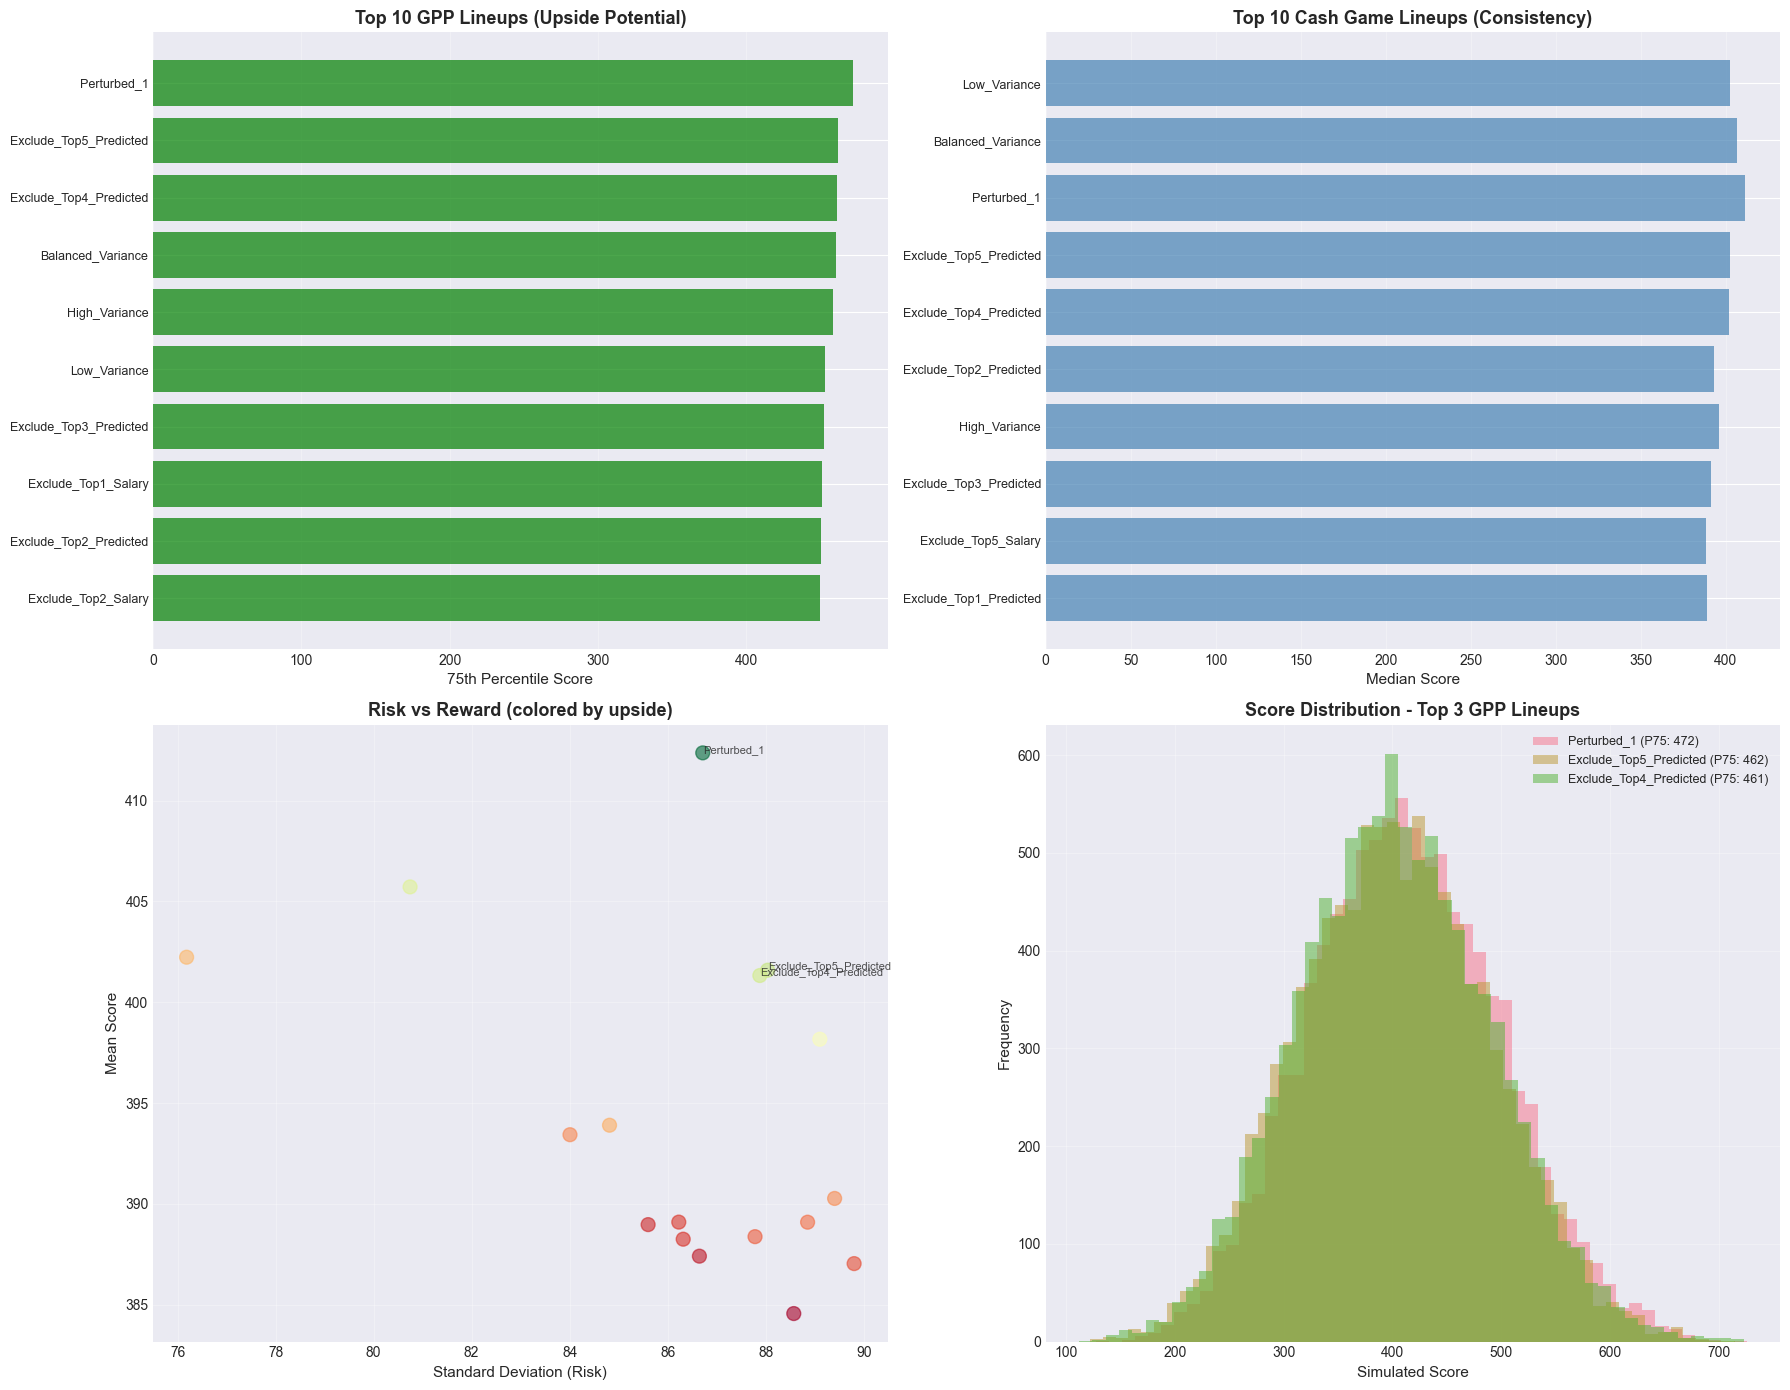

In [30]:
# Visualize lineup comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 10 GPP lineups - Upside (P75)
top_gpp = gpp_comparison.head(10)
axes[0, 0].barh(range(len(top_gpp)), top_gpp['MC_P75'], color='green', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_gpp)))
axes[0, 0].set_yticklabels(top_gpp['Strategy'], fontsize=9)
axes[0, 0].set_xlabel('75th Percentile Score', fontsize=11)
axes[0, 0].set_title('Top 10 GPP Lineups (Upside Potential)', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, axis='x', alpha=0.3)

# Top 10 Cash lineups - Consistency
top_cash = cash_comparison.head(10)
axes[0, 1].barh(range(len(top_cash)), top_cash['MC_Median'], color='steelblue', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_cash)))
axes[0, 1].set_yticklabels(top_cash['Strategy'], fontsize=9)
axes[0, 1].set_xlabel('Median Score', fontsize=11)
axes[0, 1].set_title('Top 10 Cash Game Lineups (Consistency)', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, axis='x', alpha=0.3)

# Risk vs Reward scatter (Mean vs Std Dev)
axes[1, 0].scatter(gpp_comparison['MC_Std'], gpp_comparison['MC_Mean'], 
                  c=gpp_comparison['MC_P75'], cmap='RdYlGn', s=100, alpha=0.6)
axes[1, 0].set_xlabel('Standard Deviation (Risk)', fontsize=11)
axes[1, 0].set_ylabel('Mean Score', fontsize=11)
axes[1, 0].set_title('Risk vs Reward (colored by upside)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Annotate top 3 GPP lineups
for idx, row in gpp_comparison.head(3).iterrows():
    axes[1, 0].annotate(row['Strategy'], 
                       (row['MC_Std'], row['MC_Mean']),
                       fontsize=8, alpha=0.8)

# Distribution comparison of top 3 lineups
top_3_lineups = gpp_comparison.head(3)
for i, (idx, lineup) in enumerate(top_3_lineups.iterrows()):
    mc_stats = lineup['mc_stats']
    axes[1, 1].hist(mc_stats['simulations'], bins=50, alpha=0.5, 
                   label=f"{lineup['Strategy']} (P75: {lineup['MC_P75']:.0f})")

axes[1, 1].set_xlabel('Simulated Score', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Score Distribution - Top 3 GPP Lineups', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Final Lineup Recommendations

In [31]:
# Best GPP Lineup (Tournament Play - Maximize Upside)
best_gpp = gpp_comparison.iloc[0]
best_gpp_lineup = best_gpp['lineup_obj']

print("=" * 90)
print("🏆 BEST GPP LINEUP (Tournament Play)")
print("=" * 90)
print(f"\nStrategy: {best_gpp['Strategy']}")
print(f"Description: {best_gpp['Description']}")
print(f"\nMonte Carlo Results ({10000:,} simulations using empirical distributions):")
print(f"  Mean Score:        {best_gpp['MC_Mean']:.1f} points")
print(f"  Median Score:      {best_gpp['MC_Median']:.1f} points")
print(f"  75th Percentile:   {best_gpp['MC_P75']:.1f} points ⭐")
print(f"  95th Percentile:   {best_gpp['MC_P95']:.1f} points")
print(f"  Std Deviation:     {best_gpp['MC_Std']:.1f} points")
print(f"  Skewness:          {best_gpp['Skewness']:.2f}")
print(f"  Total Salary:      ${best_gpp['Total_Salary']:,.0f} / $60,000")
print(f"  Remaining:         ${60000 - best_gpp['Total_Salary']:,.0f}")

print("\n" + "-" * 90)
print("PLAYERS:")
print("-" * 90)

gpp_display = best_gpp_lineup[['player_name', 'salary', 'predicted_pts', 'value']].copy()
gpp_display = gpp_display.sort_values('predicted_pts', ascending=False)
gpp_display.index = range(1, len(gpp_display) + 1)

for idx, row in gpp_display.iterrows():
    print(f"{idx}. {row['player_name']:30s} ${row['salary']:>6,.0f}  {row['predicted_pts']:>6.1f} pts  (Value: {row['value']:.2f})")

print("=" * 90)

🏆 BEST GPP LINEUP (Tournament Play)

Strategy: Perturbed_1
Description: Prediction perturbation (variation 1)

Monte Carlo Results (10,000 simulations using empirical distributions):
  Mean Score:        412.4 points
  Median Score:      410.5 points
  75th Percentile:   471.7 points ⭐
  95th Percentile:   559.2 points
  Std Deviation:     86.7 points
  Skewness:          0.11
  Total Salary:      $60,000 / $60,000
  Remaining:         $0

------------------------------------------------------------------------------------------
PLAYERS:
------------------------------------------------------------------------------------------
1. Young, Cameron                 $11,800   102.6 pts  (Value: 8.70)
2. Kim, Si Woo                    $11,100    99.9 pts  (Value: 9.00)
3. Rodgers, Patrick               $ 9,000    93.8 pts  (Value: 10.43)
4. Schauffele, Xander             $12,000    92.0 pts  (Value: 7.67)
5. Brennan, Michael               $ 8,400    89.5 pts  (Value: 10.66)
6. Ford, David    

In [32]:
# Best Cash Game Lineup (50/50s, Double-Ups - Minimize Risk)
best_cash = cash_comparison.iloc[0]
best_cash_lineup = best_cash['lineup_obj']

print("=" * 90)
print("💰 BEST CASH GAME LINEUP (50/50s, Double-Ups)")
print("=" * 90)
print(f"\nStrategy: {best_cash['Strategy']}")
print(f"Description: {best_cash['Description']}")
print(f"\nMonte Carlo Results ({10000:,} simulations using empirical distributions):")
print(f"  Mean Score:        {best_cash['MC_Mean']:.1f} points")
print(f"  Median Score:      {best_cash['MC_Median']:.1f} points ⭐")
print(f"  75th Percentile:   {best_cash['MC_P75']:.1f} points")
print(f"  Std Deviation:     {best_cash['MC_Std']:.1f} points")
print(f"  Skewness:          {best_cash['Skewness']:.2f}")
print(f"  Sharpe Ratio:      {best_cash['Sharpe']:.2f}")
print(f"  Total Salary:      ${best_cash['Total_Salary']:,.0f} / $60,000")
print(f"  Remaining:         ${60000 - best_cash['Total_Salary']:,.0f}")

print("\n" + "-" * 90)
print("PLAYERS:")
print("-" * 90)

cash_display = best_cash_lineup[['player_name', 'salary', 'predicted_pts', 'value']].copy()
cash_display = cash_display.sort_values('predicted_pts', ascending=False)
cash_display.index = range(1, len(cash_display) + 1)

for idx, row in cash_display.iterrows():
    print(f"{idx}. {row['player_name']:30s} ${row['salary']:>6,.0f}  {row['predicted_pts']:>6.1f} pts  (Value: {row['value']:.2f})")

print("=" * 90)

💰 BEST CASH GAME LINEUP (50/50s, Double-Ups)

Strategy: Low_Variance
Description: Low variance players (consistent)

Monte Carlo Results (10,000 simulations using empirical distributions):
  Mean Score:        403.7 points
  Median Score:      402.8 points ⭐
  75th Percentile:   455.0 points
  Std Deviation:     76.5 points
  Skewness:          0.07
  Sharpe Ratio:      0.01
  Total Salary:      $55,600 / $60,000
  Remaining:         $4,400

------------------------------------------------------------------------------------------
PLAYERS:
------------------------------------------------------------------------------------------
1. Schauffele, Xander             $12,000    92.0 pts  (Value: 7.67)
2. Scott, Adam                    $ 9,800    87.1 pts  (Value: 8.89)
3. Bezuidenhout, Christiaan       $ 8,900    83.5 pts  (Value: 9.39)
4. McCarthy, Denny                $ 9,300    82.6 pts  (Value: 8.88)
5. Meissner, Mac                  $ 8,100    81.9 pts  (Value: 10.11)
6. Phillips, Chan

In [33]:
# Export enhanced results
best_gpp_lineup[['player_name', 'salary', 'predicted_pts', 'value']].to_csv(
    'best_gpp_lineup_2026.csv', index=False
)

best_cash_lineup[['player_name', 'salary', 'predicted_pts', 'value']].to_csv(
    'best_cash_lineup_2026.csv', index=False
)

# Export full comparison table
gpp_comparison[['Rank', 'Strategy', 'Description', 'Total_Salary', 'MC_Mean', 
                'MC_Median', 'MC_P75', 'MC_P95', 'MC_Std', 'Skewness']].to_csv(
    'lineup_comparison_gpp.csv', index=False
)

cash_comparison[['Rank', 'Strategy', 'Description', 'Total_Salary', 'MC_Mean', 
                 'MC_Median', 'MC_P75', 'MC_Std', 'Skewness']].to_csv(
    'lineup_comparison_cash.csv', index=False
)

print("✓ Enhanced results exported:")
print("  - best_gpp_lineup_2026.csv (Tournament play)")
print("  - best_cash_lineup_2026.csv (Cash games)")
print("  - lineup_comparison_gpp.csv (All lineups ranked for GPP)")
print("  - lineup_comparison_cash.csv (All lineups ranked for Cash)")

✓ Enhanced results exported:
  - best_gpp_lineup_2026.csv (Tournament play)
  - best_cash_lineup_2026.csv (Cash games)
  - lineup_comparison_gpp.csv (All lineups ranked for GPP)
  - lineup_comparison_cash.csv (All lineups ranked for Cash)


In [34]:
# Calculate percentiles and risk metrics
print("\n" + "="*80)
print("MONTE CARLO RISK ANALYSIS")
print("="*80 + "\n")

percentiles = [5, 10, 25, 50, 75, 90, 95]
print("Score Percentiles:")
for p in percentiles:
    score = np.percentile(mc_results['simulations'], p)
    print(f"  {p:2d}th percentile: {score:.1f} points")

print(f"\nDownside Risk (below mean):")
below_mean = [s for s in mc_results['simulations'] if s < mc_results['mean']]
print(f"  Probability: {len(below_mean) / len(mc_results['simulations']) * 100:.1f}%")
print(f"  Average shortfall: {mc_results['mean'] - np.mean(below_mean):.1f} points")

print(f"\nUpside Potential (above 75th percentile):")
above_75 = [s for s in mc_results['simulations'] if s > mc_results['percentile_75']]
print(f"  Probability: {len(above_75) / len(mc_results['simulations']) * 100:.1f}%")
print(f"  Average surplus: {np.mean(above_75) - mc_results['percentile_75']:.1f} points")


MONTE CARLO RISK ANALYSIS

Score Percentiles:
   5th percentile: 487.3 points
  10th percentile: 506.5 points
  25th percentile: 535.0 points
  50th percentile: 566.4 points
  75th percentile: 598.3 points
  90th percentile: 627.3 points
  95th percentile: 643.4 points

Downside Risk (below mean):
  Probability: 50.1%
  Average shortfall: 37.5 points

Upside Potential (above 75th percentile):
  Probability: 25.0%
  Average surplus: 27.9 points


## 11. Export Results

In [35]:
# Export optimal lineup
optimal_lineup[['player_name', 'salary', 'predicted_pts', 'value']].to_csv(
    'optimal_lineup_2026.csv', index=False
)

# Export all predictions
upcoming_features[['player_name', 'salary', 'predicted_pts', 'value', 'predicted_std']].to_csv(
    'all_predictions_2026.csv', index=False
)

print("✓ Results exported:")
print("  - optimal_lineup_2026.csv")
print("  - all_predictions_2026.csv")

✓ Results exported:
  - optimal_lineup_2026.csv
  - all_predictions_2026.csv


## Summary

This notebook provides a complete workflow for DFS golf optimization:

1. ✓ Data loading and cleaning
2. ✓ Feature engineering with rolling statistics
3. ✓ Course similarity analysis
4. ✓ Model training and validation (tested on 2025 data)
5. ✓ Predictions for 2026 Farmers Insurance Open
6. ✓ Linear programming optimization for lineup selection
7. ✓ Alternative lineup strategies (value, contrarian)
8. ✓ Monte Carlo simulation for risk assessment

**Next Steps:**
- Monitor actual results and update model
- Incorporate ownership projections
- Add course-specific features (Torrey Pines characteristics)
- Experiment with ensemble methods
- Build multi-lineup optimizer for GPPs